In [1]:
import scanpy as sc
import scvi
import numpy as np
import sys
sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "../../data/obesity_challenge_2.h5ad"
)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import sys
sys.path.append('../')
from scripts.pairing import assign_state_label
adata.obs["cell_state"] = assign_state_label(
    adata.obs
)
print(adata.obs["cell_state"].value_counts())

cell_state
other         43319
pre_adipo     26681
adipo         16057
lipo_adipo     4758
Name: count, dtype: int64


In [3]:
MIN_CELLS = 30

cell_counts = adata.obs['gene'].value_counts()

valid_perts = cell_counts[cell_counts >= MIN_CELLS].index

adata = adata[adata.obs['gene'].isin(valid_perts)].copy()

print("before:", adata.shape)
print("condition:",  adata.obs['gene'].unique())

before: (90312, 36601)
condition: ['CEBPA+CEBPD', 'STAT5A', 'STAT5B', 'CEBPB', 'ZBED3', ..., 'STAT5A+STAT5A', 'TCF7L2+TCF7L2', 'CEBPA+POLR2D', 'CEBPB+KIF11', 'KIF11+PPARG']
Length: 127
Categories (127, object): ['CEBPA+CEBPA', 'CEBPA+CEBPB', 'CEBPA+CEBPD', 'CEBPA+CREB1', ..., 'TCF7L2', 'TCF7L2+TCF7L2', 'TCF7L2+ZBED3', 'ZBED3']


In [4]:
import pandas as pd

val_df = pd.read_csv(
    "../../data/preprocessed/val_perts/validation_mapping.csv"
)

val_condition = val_df["val_pert"].unique().tolist()

print(len(val_condition))
print(val_condition[:10])

34
['CEBPD+CREB1', 'KIF11+MLXIPL', 'CEBPD+SREBF1', 'CEBPD+ZBED3', 'CEBPB+PPARG', 'CEBPB+FOXO1', 'CEBPA+MLXIPL', 'STAT5A+TCF7L2', 'MLXIPL+STAT5A', 'CEBPB+NC']


In [5]:
adata_train = adata[
    ~adata.obs["gene"].isin(val_condition)
].copy()

adata_test = adata[
    adata.obs["gene"].isin(val_condition)
].copy()

In [31]:
adata_train_subset, hvg_genes,sig_genes = subset_to_hvg(
    adata_train,
    hvg_path="../../data/preprocessed/HVG/pertubation_genes.txt",
    include_signature_genes=True
)

adata_test_subset, hvg_genes,sig_genes = subset_to_hvg(
    adata_test,
    hvg_path="../../data/preprocessed/HVG/pertubation_genes.txt",
    include_signature_genes=True
)

HVG requested: 1939
Signature genes requested: 820
Signature genes used: 607
Total genes used: 2546
HVG requested: 1939
Signature genes requested: 820
Signature genes used: 607
Total genes used: 2546


In [6]:
# load model
scanvi = scvi.model.SCVI.load(
    "../../resources/scvi_model_all_genes_50",
    adata=adata_train
)

# mapping
scvi.model.SCVI.prepare_query_anndata(
    adata_train,
    scanvi
)

# latent
adata_train.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_train
    )
)

print("latent shape:")
print(adata_train.obsm["X_scanvi"].shape)

import gc

# 刪除不再需要的物件
del adata

# 強制 python 釋放記憶體
gc.collect()

INFO     File ../../resources/scvi_model_all_genes_50/model.pt already downloaded                                  


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


INFO     Found 100.0% reference vars in query data.                                                                
latent shape:
(86190, 50)


962

In [7]:
# load model
scanvi = scvi.model.SCVI.load(
    "../../resources/scvi_model_all_genes_50",
    adata=adata_test
)

# mapping
scvi.model.SCVI.prepare_query_anndata(
    adata_test,
    scanvi
)

# latent
adata_test.obsm["X_scanvi"] = (
    scanvi.get_latent_representation(
        adata_test
    )
)

print("latent shape:")
print(adata_test.obsm["X_scanvi"].shape)

INFO     File ../../resources/scvi_model_all_genes_50/model.pt already downloaded                                  
INFO     Found 100.0% reference vars in query data.                                                                


/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/scvi/model/base/_base_model.py:862: UserWarning: `accelerator` has been automatically set to `cpu` although 'mps' exists. If you wish to run on mps backend, use explicitly accelerator='mps' in train function.In future releases it will become default for mps supported machines.
  _, _, device = parse_device_args(


latent shape:
(4122, 50)


In [8]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------
# flow block
# ---------------------------------------------------------

class FlowBlock(nn.Module):

    def __init__(
        self,
        latent_dim=50,
        cond_out_dim=64,
        time_dim=32,
        hidden=512,
        depth=2
    ):
        super().__init__()

        input_dim = latent_dim + time_dim + cond_out_dim

        layers = [
            nn.Linear(input_dim, hidden),
            nn.SiLU()
        ]

        for _ in range(depth):

            layers.append(
                nn.Linear(hidden, hidden)
            )

            layers.append(
                nn.SiLU()
            )

        layers.append(
            nn.Linear(hidden, latent_dim)
        )

        self.net = nn.Sequential(*layers)


    def forward(
        self,
        x,
        t_emb,
        cond_latent
    ):

        h = torch.cat(
            [
                x,
                t_emb,
                cond_latent
            ],
            dim=1
        )

        dx = self.net(h)

        return dx




# ---------------------------------------------------------
# flow model
# ---------------------------------------------------------

class FlowMLP(nn.Module):

    def __init__(
        self,
        latent_dim=50,
        cond_dim=1536,
        cond_out=64,
        n_flows=1,
        time_dim=32,
        cond_hidden = 512,
        hidden=512,
        depth=2,
        dropout = 0
    ):

        super().__init__()

        self.time_dim = time_dim


        # deeper condition encoder
        self.cond_net = nn.Sequential(

            nn.Linear(cond_dim, 512),
            nn.SiLU(),

            nn.Linear(512, 256),
            nn.SiLU(),

            nn.Linear(256, 128),
            nn.SiLU(),

            nn.Linear(128, cond_out),
            nn.SiLU()

        )


        self.blocks = nn.ModuleList(

            [

                FlowBlock(

                    latent_dim=latent_dim,

                    cond_out_dim=cond_out,

                    time_dim=time_dim,

                    hidden=hidden,

                    depth=depth

                )

                for _ in range(n_flows)

            ]

        )


    def forward(
        self,
        x,
        t,
        cond
    ):

        # -------------------------------------------------
        # normalize condition embedding
        # -------------------------------------------------

        cond = F.normalize(cond, dim=1)


        cond_latent = self.cond_net(cond)


        t_emb = fourier_time_embedding(

            t,

            dim=self.time_dim

        )


        step_scale = 1.0 / len(self.blocks)


        for block in self.blocks:

            dx = block(

                x,

                t_emb,

                cond_latent

            )

            x = x + step_scale * dx


        return x

In [9]:
import math
import json
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import linear_sum_assignment
from sklearn.neighbors import NearestNeighbors

from scripts.pairing import get_condition_encoder


# =========================================================
# 3. dataset
# =========================================================

class ConditionalFlowDataset(Dataset):
    """
    Online sampler for conditional flow matching.

    Each __getitem__ samples:
        condition c
        z1 ~ p_data(z | c)
        z0 ~ N(0, I)
    """

    def __init__(
        self,
        adata,
        encode_condition_fn,
        latent_key="X_scanvi",
        gene_col="gene",
        dataset_size=200_000,
        random_state=0,
        include_conditions=None
    ):
        self.adata = adata
        self.latent = np.asarray(adata.obsm[latent_key], dtype=np.float32)
        self.genes = adata.obs[gene_col].values
        self.encode_condition_fn = encode_condition_fn
        self.dataset_size = int(dataset_size)

        self.rng = np.random.default_rng(random_state)

        self.pert_to_idx = {}
        unique_perts = np.unique(self.genes)

        for pert in unique_perts:
            idx = np.where(self.genes == pert)[0]
            if len(idx) > 0:
                self.pert_to_idx[pert] = idx

        if include_conditions is not None:
            include_conditions = set(include_conditions)
            self.pert_to_idx = {
                k: v for k, v in self.pert_to_idx.items()
                if k in include_conditions
            }

        self.perts = sorted(list(self.pert_to_idx.keys()))

        if len(self.perts) == 0:
            raise ValueError("No perturbations found for dataset")

        self.latent_dim = self.latent.shape[1]

        # infer condition dimension from first perturbation
        test_cond = self.encode_condition_fn(self.perts[0])
        self.cond_dim = int(test_cond.shape[0])

    def __len__(self):
        return self.dataset_size

    def __getitem__(self, idx):
        pert = self.rng.choice(self.perts)

        z1_idx = self.rng.choice(self.pert_to_idx[pert])
        z1 = self.latent[z1_idx]

        z0 = self.rng.normal(
            loc=0.0,
            scale=1.0,
            size=self.latent_dim
        ).astype(np.float32)

        cond = self.encode_condition_fn(pert)

        return (
            torch.from_numpy(z0),
            torch.from_numpy(z1),
            torch.from_numpy(cond),
            pert
        )


# =========================================================
# 4. time embedding
# =========================================================

def fourier_time_embedding(
    t,
    dim=64,
    max_period=10000.0
):
    """
    Sinusoidal / Fourier time embedding.

    Parameters
    ----------
    t : torch.Tensor
        shape = (B, 1), values in [0, 1]
    dim : int
        embedding dimension
    max_period : float
        frequency scale

    Returns
    -------
    emb : torch.Tensor
        shape = (B, dim)
    """
    if t.ndim != 2 or t.shape[1] != 1:
        raise ValueError(f"t must have shape (B,1), got {tuple(t.shape)}")

    half_dim = dim // 2
    device = t.device
    dtype = t.dtype

    freqs = torch.exp(
        -math.log(max_period) * torch.arange(
            0, half_dim, device=device, dtype=dtype
        ) / max(half_dim - 1, 1)
    )

    # scale by 2pi so periodicity is more expressive
    args = 2.0 * math.pi * t * freqs.unsqueeze(0)

    emb = torch.cat(
        [torch.sin(args), torch.cos(args)],
        dim=1
    )

    if dim % 2 == 1:
        emb = torch.cat(
            [emb, torch.zeros((t.shape[0], 1), device=device, dtype=dtype)],
            dim=1
        )

    return emb


# =========================================================
# 5. model
# =========================================================
import torch
import torch.nn as nn
import torch.nn.functional as F



# ------------------------------------------------------------
# Residual MLP block with time conditioning + dropout
# ------------------------------------------------------------


# =========================================================
# 6. flow matching loss
# =========================================================

def flow_matching_loss(
    model,
    z0,
    z1,
    cond
):
    """
    Standard conditional flow matching loss with straight-line interpolation.

    z_t = (1 - t) z0 + t z1
    target velocity = z1 - z0
    """
    batch_size = z0.shape[0]
    device = z0.device

    t = torch.rand(batch_size, 1, device=device, dtype=z0.dtype)
    # noise augmentation 
    z1 = z1 + 0.05*torch.randn_like(z1)
    xt = (1.0 - t) * z0 + t * z1
    target = z1 - z0

    pred = model(xt, t, cond)

    loss = ((pred - target) ** 2).mean()
    return loss


# =========================================================
# 7. training
# =========================================================

def train_flow_model(
    adata,
    embedding_dict,
    cond_out_dim = 32,
    time_dim = 4,
    latent_key="X_scanvi",
    gene_col="gene",
    add_num_guides=True,
    normalize_embedding=False,
    batch_size=256,
    dataset_size=200_000,
    max_epochs=200,
    lr=1e-3,
    weight_decay=1e-4,
    device=None,
    random_state=0,
    model_save_path="best_flow_model.pt",
    num_workers=0
):
    if device is None:
        if torch.backends.mps.is_available():
            device = "mps"
        elif torch.cuda.is_available():
            device = "cuda"
        else:
            device = "cpu"

    encode_fn = get_condition_encoder(
        condition_mode="embedding",
        embedding_dict=embedding_dict,
        add_num_guides=add_num_guides,
    )
    all_perts = np.unique(adata.obs[gene_col])

    rng = np.random.default_rng(random_state)

    rng.shuffle(all_perts)

    split = int(len(all_perts) * 0.8)

    train_perts = all_perts[:split]
    val_perts   = all_perts[split:]
    
    val_dataset = ConditionalFlowDataset(
        adata=adata,
        encode_condition_fn=encode_fn,
        latent_key=latent_key,
        gene_col=gene_col,
        dataset_size=dataset_size,
        random_state=random_state, 
        include_conditions=val_perts
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=True
    )

    dataset = ConditionalFlowDataset(
        adata=adata,
        encode_condition_fn=encode_fn,
        latent_key=latent_key,
        gene_col=gene_col,
        dataset_size=dataset_size,
        random_state=random_state, 
        include_conditions=train_perts
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True,
        drop_last=True,
        num_workers=num_workers
    )

    model = FlowMLP(
        latent_dim=dataset.latent_dim,
        cond_dim=dataset.cond_dim,
        time_dim=time_dim,
        cond_hidden=512,
        cond_out=cond_out_dim,
        hidden=512,
        depth=3,
        dropout=0.1
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = []
    best_loss = float("inf")

    print(f"device: {device}")
    print(f"latent_dim: {dataset.latent_dim}")
    print(f"cond_dim: {dataset.cond_dim}")
    print(f"n_conditions: {len(dataset.perts)}")
    print("conditions:")
    print(dataset.perts)
    
    history = {
        "train": [],
        "val": []
    }

    best_loss = float("inf")

    for epoch in range(max_epochs):

        # =====================
        # train
        # =====================
        model.train()

        train_losses = []

        for z0, z1, cond, pert in loader:

            z0 = z0.to(device, dtype=torch.float32)
            z1 = z1.to(device, dtype=torch.float32)
            cond = cond.to(device, dtype=torch.float32)

            loss = flow_matching_loss(
                model=model,
                z0=z0,
                z1=z1,
                cond=cond
            )

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())


        train_loss = float(np.mean(train_losses))


        # =====================
        # validation
        # =====================
        model.eval()

        val_losses = []

        with torch.no_grad():

            for z0, z1, cond, _ in val_loader:

                z0 = z0.to(device, dtype=torch.float32)
                z1 = z1.to(device, dtype=torch.float32)
                cond = cond.to(device, dtype=torch.float32)

                loss = flow_matching_loss(
                    model,
                    z0,
                    z1,
                    cond
                )

                val_losses.append(loss.item())


        val_loss = float(np.mean(val_losses))


        # =====================
        # record history
        # =====================
        history["train"].append(train_loss)
        history["val"].append(val_loss)


        # =====================
        # save best model (用 val)
        # =====================
        if val_loss < best_loss:

            best_loss = val_loss

            torch.save(
                {
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),

                    "history": history,

                    "latent_dim": dataset.latent_dim,
                    "cond_dim": dataset.cond_dim,

                    "time_dim": time_dim,

                    "cond_out_dim": cond_out_dim,

                    "add_num_guides": add_num_guides,
                    "normalize_embedding": normalize_embedding,

                    "latent_key": latent_key,
                    "gene_col": gene_col,

                    "train_perts": dataset.perts,
                    "val_perts": val_dataset.perts,
                },
                model_save_path
            )


        # =====================
        # logging
        # =====================
        print(
                f"epoch {epoch:03d} | "
                f"train {train_loss:.6f} | "
                f"val {val_loss:.6f} | "
                f"best {best_loss:.6f}"
            )


    return model, history, dataset

# =========================================================
# 8. ODE sampling / inference
# =========================================================

@torch.no_grad()
def sample_latent_cells(
    model,
    condition,
    encode_condition_fn,
    latent_dim,
    n_cells=100,
    n_steps=100,
    device="cpu",
    z0=None
):
    """
    Generate latent samples for one condition using Euler ODE integration.

    dz/dt = v_theta(z, t, cond)
    """
    model.eval()

    if z0 is None:
        z = torch.randn(n_cells, latent_dim, device=device)
    else:
        z = torch.as_tensor(z0, dtype=torch.float32, device=device)
        if z.shape != (n_cells, latent_dim):
            raise ValueError(
                f"z0 shape must be {(n_cells, latent_dim)}, got {tuple(z.shape)}"
            )

    cond_vec = encode_condition_fn(condition)
    cond = torch.tensor(cond_vec, dtype=torch.float32, device=device).unsqueeze(0)
    cond = cond.repeat(n_cells, 1)

    dt = 1.0 / n_steps

    for step in range(n_steps):
        t_scalar = step / n_steps
        t = torch.full(
            (n_cells, 1),
            fill_value=t_scalar,
            device=device,
            dtype=torch.float32
        )

        v = model(z, t, cond)
        z = z + dt * v

    return z.detach().cpu().numpy()


# =========================================================
# 9. helper for batch generation
# =========================================================

@torch.no_grad()
def generate_for_conditions(
    model,
    conditions,
    encode_condition_fn,
    latent_dim,
    n_cells_per_condition=100,
    n_steps=100,
    device="cpu"
):
    """
    Generate latent samples for multiple perturbations.

    Returns
    -------
    generated_latents : np.ndarray
        shape = (sum cells, latent_dim)
    obs_df : pd.DataFrame
        contains gene column
    """
    all_latents = []
    all_obs = []

    for cond in conditions:
        z = sample_latent_cells(
            model=model,
            condition=cond,
            encode_condition_fn=encode_condition_fn,
            latent_dim=latent_dim,
            n_cells=n_cells_per_condition,
            n_steps=n_steps,
            device=device
        )

        all_latents.append(z)

        obs_df = pd.DataFrame({
            "gene": [cond] * n_cells_per_condition
        })
        all_obs.append(obs_df)

    generated_latents = np.vstack(all_latents).astype(np.float32)
    obs_df = pd.concat(all_obs, axis=0, ignore_index=True)

    return generated_latents, obs_df


In [10]:
import sys
sys.path.append('../')
from scripts.pairing import load_gene_embeddings


emb = load_gene_embeddings("large")
model, history, dataset = train_flow_model(
    adata=adata_train,
    embedding_dict=emb,
    cond_out_dim = 32,
    time_dim = 8,
    latent_key="X_scanvi",
    gene_col="gene",
    add_num_guides=False,
    normalize_embedding=False,
    batch_size=512,
    dataset_size=10000,
    max_epochs=100,
    lr=1e-4,
    weight_decay=1e-5,
    device="mps",   # or "cuda" / "cpu"
    random_state=0,
    model_save_path="try_best_flow_model.pt",
    num_workers=0
)

device: mps
latent_dim: 50
cond_dim: 3072
n_conditions: 74
conditions:
['CEBPA+CEBPA', 'CEBPA+CEBPB', 'CEBPA+CEBPD', 'CEBPA+FOXO1', 'CEBPA+KIF11', 'CEBPA+NC', 'CEBPA+NR3C1', 'CEBPA+SF3B1', 'CEBPB', 'CEBPB+CEBPB', 'CEBPB+CEBPD', 'CEBPB+KIF11', 'CEBPB+POLR2D', 'CEBPD+KIF11', 'CEBPD+KLF15', 'CEBPD+MLXIPL', 'CEBPD+POLR2D', 'CEBPD+SF3B1', 'CEBPD+STAT5A', 'CEBPD+STAT5B', 'CEBPD+TCF7L2', 'CREB1+KLF15', 'CREB1+NR3C1', 'CREB1+POLR2D', 'CREB1+SF3B1', 'CREB1+SREBF1', 'CREB1+TCF7L2', 'CREB1+ZBED3', 'FOXO1+KLF15', 'FOXO1+STAT5A', 'FOXO1+TCF7L2', 'KIF11', 'KIF11+KLF15', 'KIF11+NR3C1', 'KIF11+PPARG2', 'KIF11+SREBF1', 'KIF11+TCF7L2', 'KLF15+KLF15', 'KLF15+NR3C1', 'KLF15+POLR2D', 'KLF15+SREBF1', 'KLF15+STAT5A', 'KLF15+TCF7L2', 'KLF15+ZBED3', 'MLXIPL+NR3C1', 'MLXIPL+POLR2D', 'MLXIPL+SREBF1', 'MLXIPL+ZBED3', 'NC+NR3C1', 'NC+POLR2D', 'NC+STAT5A', 'NC+STAT5A+ZBED3', 'NC+STAT5B', 'NC+ZBED3', 'NR3C1', 'NR3C1+NR3C1', 'NR3C1+POLR2D', 'NR3C1+SF3B1', 'NR3C1+STAT5A', 'NR3C1+STAT5B', 'NR3C1+ZBED3', 'POLR2D+SREBF1'

In [23]:
import sys
sys.path.append('../')
from scripts.pairing import load_gene_embeddings, get_condition_encoder

emb = load_gene_embeddings("large")
ckpt = torch.load(
    "try_best_flow_model.pt",
    map_location="cpu",
        weights_only=False   # 👈 加這行

)


model = FlowMLP(

    latent_dim = ckpt["latent_dim"],

    cond_dim = ckpt["cond_dim"],

    time_dim = ckpt["time_dim"],

    cond_hidden = 512,

    cond_out = ckpt["cond_out_dim"],

    hidden = 512,

    depth =3
)

model.load_state_dict(
    ckpt["model_state_dict"]
)


# ★ 這行是關鍵
device = "mps"

model = model.to(device)

model.eval()


encode_fn = get_condition_encoder(

    embedding_dict = emb,

    add_num_guides = ckpt["add_num_guides"],

    condition_mode = "embedding"
)


generated_latents, generated_obs = generate_for_conditions(

    model = model,

    conditions = val_condition,
    encode_condition_fn = encode_fn,

    latent_dim = ckpt["latent_dim"],

    n_cells_per_condition = 100,

    n_steps = 200,

    device = device
)

In [11]:
encode_fn = get_condition_encoder(
    embedding_dict=emb,
    add_num_guides=False,
    condition_mode='embedding'
)


generated_latents, generated_obs = generate_for_conditions(
    model=model,
    conditions=val_condition,
    encode_condition_fn=encode_fn,
    latent_dim=dataset.latent_dim,
    n_cells_per_condition=100,
    n_steps=400,
    device="mps"
)

print(generated_latents.shape)

(3400, 50)


In [12]:
import torch
import numpy as np


def decode_scanvi_latent(
    scanvi_model,
    latent,
    library_size=1e5,
    batch_size=512,
    device="cpu",
    mode="scale",
):

    device = torch.device(device)

    latent_t = torch.tensor(
        latent,
        dtype=torch.float32,
        device=device
    )

    decoder = scanvi_model.module.decoder
    dispersion = scanvi_model.module.dispersion

    outputs = []

    for i in range(0, latent_t.shape[0], batch_size):

        z = latent_t[i:i+batch_size]

        ##################################
        # library size
        ##################################

        library = torch.log(
            torch.ones(
                (z.shape[0], 1),
                device=device
            ) * library_size
        )

        ##################################
        # categorical covariates
        ##################################

        batch_index = torch.zeros(
            (z.shape[0], 1),
            dtype=torch.long,
            device=device
        )

        y = torch.zeros(
            (z.shape[0], 1),
            dtype=torch.long,
            device=device
        )

        ##################################
        # decode
        ##################################

        with torch.no_grad():

            px_scale, px_r, px_rate, px_dropout = decoder(

                dispersion,
                z,
                library,
                batch_index,
                y
            )

        ##################################
        # choose expression type
        ##################################

        if mode == "scale":

            expr = px_scale * library_size

        elif mode == "rate":

            expr = px_rate

        else:

            raise ValueError("mode must be scale or rate")

        outputs.append(

            expr.cpu().numpy()

        )

    return np.concatenate(outputs, axis=0)

In [ ]:
gene_pred_decode = decode_scanvi_latent(
    scanvi,
    generated_latents,
    library_size=1e5,
    device="cpu",
)

gene_pred_decode

In [13]:
from scripts.scoring import latent_to_expression_nn
gene_pred_nn = latent_to_expression_nn(

    latent_query = generated_latents,

    latent_train = adata_train.obsm["X_scanvi"],

    adata_train = adata_train,

    k = 1,

    method = "softmax" #distance,mean,softmax
)

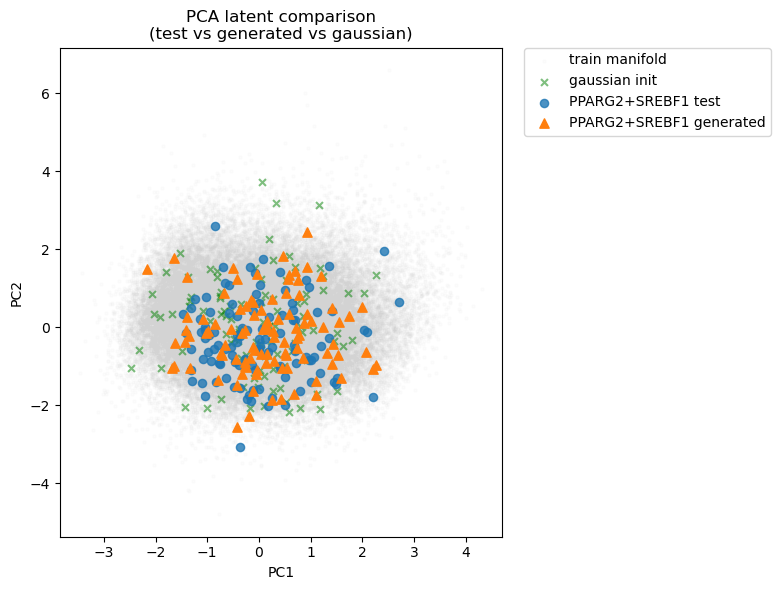

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


########################################
# choose genes
########################################

genes_of_interest = [

 'PPARG2+SREBF1',


]


########################################
# latent
########################################

X_train = adata_train.obsm["X_scanvi"]

X_test  = adata_test.obsm["X_scanvi"]

X_pred  = generated_latents


########################################
# gene labels
########################################

test_gene_labels = adata_test.obs["gene"].values

pred_gene_labels = generated_obs["gene"].values


########################################
# subset indices
########################################

test_mask = np.isin(

    test_gene_labels,

    genes_of_interest
)

pred_mask = np.isin(

    pred_gene_labels,

    genes_of_interest
)


X_test_sub = X_test[test_mask]

X_pred_sub = X_pred[pred_mask]


test_gene_sub = test_gene_labels[test_mask]

pred_gene_sub = pred_gene_labels[pred_mask]


########################################
# gaussian init
########################################

n_gauss = X_pred_sub.shape[0]

X_gauss = np.random.normal(

    loc=0,
    scale=1,

    size=(n_gauss, X_train.shape[1])
)


########################################
# PCA fit on train+test
########################################

X_fit = np.vstack([

    X_train,
    X_test

])

pca_2d = PCA(

    n_components=2,

    random_state=42
)

pca_2d.fit(X_fit)


########################################
# transform
########################################

X_train_2d = pca_2d.transform(X_train)

X_test_2d  = pca_2d.transform(X_test_sub)

X_pred_2d  = pca_2d.transform(X_pred_sub)

X_gauss_2d = pca_2d.transform(X_gauss)


########################################
# plot
########################################

plt.figure(figsize=(8,6))


####################
# train background
####################

plt.scatter(

    X_train_2d[:,0],
    X_train_2d[:,1],

    color="lightgrey",

    alpha=0.05,

    s=5,

    label="train manifold"
)


####################
# gaussian init
####################

plt.scatter(

    X_gauss_2d[:,0],
    X_gauss_2d[:,1],

    color="green",

    alpha=0.5,

    s=25,

    marker="x",

    label="gaussian init"
)


####################
# plot each gene
####################

for gene in genes_of_interest:

    ####################
    # test cells
    ####################

    mask_test_gene = test_gene_sub == gene

    plt.scatter(

        X_test_2d[mask_test_gene,0],
        X_test_2d[mask_test_gene,1],

        alpha=0.8,

        s=35,

        marker="o",

        label=f"{gene} test"
    )


    ####################
    # generated cells
    ####################

    mask_pred_gene = pred_gene_sub == gene

    plt.scatter(

        X_pred_2d[mask_pred_gene,0],
        X_pred_2d[mask_pred_gene,1],

        alpha=1,

        s=45,

        marker="^",

        label=f"{gene} generated"
    )


########################################

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title("PCA latent comparison\n(test vs generated vs gaussian)")

plt.legend(

    bbox_to_anchor=(1.05,1),

    borderaxespad=0
)

plt.tight_layout()

plt.show()

In [18]:
import numpy as np


def merge_decoder_into_full_matrix(

    X_full,
    X_hvg,
    adata_full,
    scanvi_model
):
    """
    把 decoder 預測的 HVG expression 填回 full gene matrix

    Parameters
    ----------
    X_full
        (n_cells, n_all_genes)

    X_hvg
        (n_cells, n_hvg_genes)

    adata_full
        用來提供 gene name 順序

    scanvi_model
        用來取得 HVG gene list
    """

    ##################################
    # gene name list
    ##################################

    full_gene_names = adata_full.var_names.to_numpy()

    hvg_gene_names = scanvi_model.adata.var_names.to_numpy()

    ##################################
    # 找到 HVG 在 full matrix 中的位置
    ##################################

    gene_to_index = {

        g:i for i,g in enumerate(full_gene_names)

    }

    hvg_indices = [

        gene_to_index[g]

        for g in hvg_gene_names

        if g in gene_to_index

    ]

    ##################################
    # copy matrix
    ##################################

    X_merged = X_full.copy()

    ##################################
    # 覆蓋 HVG columns
    ##################################

    X_merged[:, hvg_indices] = X_hvg


    return X_merged

In [19]:
X_combined = merge_decoder_into_full_matrix(

    X_full = gene_pred_nn,

    X_hvg = gene_pred_decode,

    adata_full = adata_train,

    scanvi_model = scanvi
)

In [20]:
import numpy as np


def latent_delta_transfer(
    generated_latents,
    adata_train,
    scanvi_model,
    k=1,
    library_size=1e5,
    device="cpu",
    nn_method="softmax"
):
    """
    使用 latent delta transfer 修正 decoder bias

    Steps
    -----
    1. 找 nearest neighbor latent
    2. decode generated latent -> expr_gen_decoded
    3. decode NN latent -> expr_nn_decoded
    4. delta = expr_gen_decoded - expr_nn_decoded
    5. final = NN_ground_truth + delta

    Returns
    -------
    final_expression
        (n_cells, n_all_genes)

    delta_expression
        (n_cells, n_hvg_genes)
    """

    ##################################
    # NN search
    ##################################

    latent_train = adata_train.obsm["X_scanvi"]

    from sklearn.neighbors import NearestNeighbors

    nbrs = NearestNeighbors(
        n_neighbors=k,
        metric="euclidean"
    ).fit(latent_train)

    distances, indices = nbrs.kneighbors(generated_latents)

    ##################################
    # ground truth expression of NN
    ##################################

    X_train = adata_train.X

    if not isinstance(X_train, np.ndarray):
        X_train = X_train.toarray()

    nn_gt_expr = X_train[indices[:, 0]]

    ##################################
    # NN latent
    ##################################

    nn_latents = latent_train[indices[:, 0]]

    ##################################
    # decode generated latent
    ##################################

    expr_gen_decoded = decode_scanvi_latent(
        scanvi_model,
        generated_latents,
        library_size=library_size,
        device=device
    )

    ##################################
    # decode NN latent
    ##################################

    expr_nn_decoded = decode_scanvi_latent(
        scanvi_model,
        nn_latents,
        library_size=library_size,
        device=device
    )

    ##################################
    # delta in HVG space
    ##################################

    delta_expr = expr_gen_decoded - expr_nn_decoded

    ##################################
    # merge HVG delta into full gene space
    ##################################

    nn_gt_full = nn_gt_expr.copy()

    final_expr = merge_decoder_into_full_matrix(

        X_full = nn_gt_full,
        X_hvg = expr_gen_decoded,
        adata_full = adata_train,
        scanvi_model = scanvi_model

    )

    ##################################
    # replace HVG part with delta transfer
    ##################################

    full_gene_names = adata_train.var_names.to_numpy()
    hvg_gene_names = scanvi_model.adata.var_names.to_numpy()

    gene_to_index = {g:i for i,g in enumerate(full_gene_names)}

    hvg_indices = [
        gene_to_index[g]
        for g in hvg_gene_names
        if g in gene_to_index
    ]

    final_expr[:, hvg_indices] = (
        nn_gt_full[:, hvg_indices] + delta_expr
    )

    return final_expr, delta_expr

In [21]:
X_delta_corrected, delta = latent_delta_transfer(

    generated_latents = generated_latents,

    adata_train = adata_train,

    scanvi_model = scanvi,

    k = 1,

    library_size = 1e5,

    device = "cpu"
)

In [15]:
import importlib
import scripts.eval_flow

importlib.reload(scripts.eval_flow)

from scripts.eval_flow import evaluate_generated_expression_fast
results_df = evaluate_generated_expression_fast(

    pred_gex_matric = gene_pred_nn,

    generated_obs = generated_obs,

    conditions = val_condition,

    adata_gt_path = "../../data/obesity_challenge_2.h5ad",

    centroid_path = "../../data/preprocessed/centroid/centroid.csv",

)


Loading GT matrix...

Preparing gene sets...
{'random1000': 1000, 'hvg3000': 3000}
union genes: 3920

Preloading GT gene subset...

Evaluating CEBPD+CREB1

Evaluating KIF11+MLXIPL

Evaluating CEBPD+SREBF1

Evaluating CEBPD+ZBED3

Evaluating CEBPB+PPARG

Evaluating CEBPB+FOXO1

Evaluating CEBPA+MLXIPL

Evaluating STAT5A+TCF7L2

Evaluating MLXIPL+STAT5A

Evaluating CEBPB+NC

Evaluating CEBPD+PPARG

Evaluating PPARG+ZBED3

Evaluating PPARG+STAT5A

Evaluating NR3C1+PPARG2

Evaluating CREB1+STAT5A

Evaluating KLF15+PPARG

Evaluating PPARG2+SREBF1

Evaluating CEBPA+STAT5B

Evaluating CEBPA+CREB1

Evaluating MLXIPL+PPARG2

Evaluating PPARG2+TCF7L2

Evaluating KLF15+NC

Evaluating CEBPA+SREBF1

Evaluating CEBPA+PPARG2

Evaluating CEBPA+ZBED3

Evaluating CEBPB+TCF7L2

Evaluating NR3C1+PPARG

Evaluating PPARG2+ZBED3

Evaluating POLR2D+PPARG

Evaluating CEBPB+STAT5B

Evaluating STAT5A+ZBED3

Evaluating CEBPB+NR3C1

Evaluating SF3B1+SREBF1

Evaluating STAT5A+STAT5B

Summary
     perturbation  n_g

In [ ]:
pearson_random1000: 0.0588
mmd_random1000: 3.0496
pearson_hvg3000: 0.0448
mmd_hvg3000: 1.1285

In [ ]:
pearson_random1000: -0.0085
mmd_random1000: 0.0688
pearson_hvg3000: 0.0495
mmd_hvg3000: 0.1174